# CDO Climate Study
This notebook analyzes temperature and rainfall data for Cagayan de Oro.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from datetime import datetime
import seaborn as sns

## Helper Functions

In [2]:
def load_noaa_csv(path, value_keyword, value_colname):
    """Loads NOAA-style CSV, finds the real header, and returns a cleaned time-series DataFrame."""
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if line.strip().startswith("time,"):
                header_row = i
                break
    d = pd.read_csv(path, skiprows=header_row, parse_dates=["time"])
    col = [c for c in d.columns if value_keyword.lower() in c.lower()][0]
    d = d.rename(columns={col: value_colname})
    d[value_colname] = pd.to_numeric(d[value_colname], errors="coerce")
    d = d.dropna(subset=["time", value_colname]).set_index("time").sort_index()
    return d

def get_decades(df):
    """Groups years into decades."""
    start_year = df.index.year.min()
    end_year   = df.index.year.max()
    decades = {}
    for d in range((start_year // 10) * 10, end_year + 1, 10):
        yrs = [y for y in range(d, d + 10) if y <= end_year and y in df.index.year]
        if yrs:
            decades[d] = yrs
    return decades

def weighted_by_doy(df, value_col, agg="mean"):
    """Calculates a weighted mean by day-of-year across decades, favoring recent decades."""
    decades = get_decades(df)
    decade_means = {}
    for start, yrs in decades.items():
        stack = []
        for year in yrs:
            df_y = df[df.index.year == year]
            if df_y.empty: continue
            daily = df_y[value_col].resample("D").agg(agg)
            s = pd.Series(daily.values, index=daily.index.dayofyear)
            stack.append(s)
        if stack:
            decade_means[start] = pd.concat(stack, axis=1).mean(axis=1).sort_index()
            
    decade_df = pd.DataFrame(decade_means).sort_index()
    weights = pd.Series(np.arange(1, len(decade_df.columns) + 1), index=decade_df.columns)
    
    def wmean(row):
        mask = row.notna()
        if not mask.any(): return np.nan
        return np.average(row[mask], weights=weights[mask])
        
    weighted = decade_df.apply(wmean, axis=1)
    return decade_df, weighted

## 1. Metadata & Initial Data Load
Let's verify the metadata structure using the temperature file.

In [3]:
temp_file = "CDO_Temp2.csv"
meta = pd.read_csv(temp_file, nrows=1)
display(meta)

,latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation
0,8.471002,124.63917,9.0,0,GMT,GMT


## 2. Temperature Analysis

In [4]:
temp_df = load_noaa_csv(temp_file, "temp", "temp_C")
display(temp_df.head())
print("Data shape:", temp_df.shape)

,temp_C
time,
1940-01-06 00:00:00,26.0
1940-01-06 01:00:00,26.8
1940-01-06 02:00:00,27.2
1940-01-06 03:00:00,26.6
1940-01-06 04:00:00,26.5


Data shape: (760080, 1)


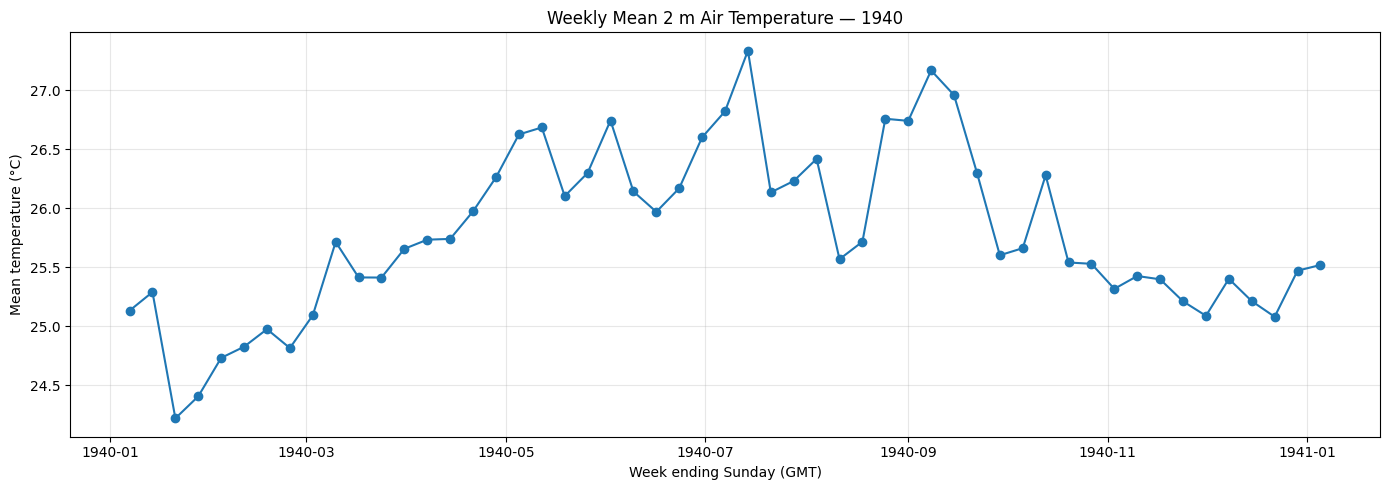

In [5]:
# Weekly Mean 2 m Air Temperature — 1940
df_1940 = temp_df[temp_df.index.year == 1940]
weekly_mean_1940 = df_1940["temp_C"].resample("W").mean()

plt.figure(figsize=(14, 5))
plt.plot(weekly_mean_1940.index, weekly_mean_1940.values, marker="o", linewidth=1.5)
plt.title("Weekly Mean 2 m Air Temperature — 1940")
plt.xlabel("Week ending Sunday (GMT)")
plt.ylabel("Mean temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

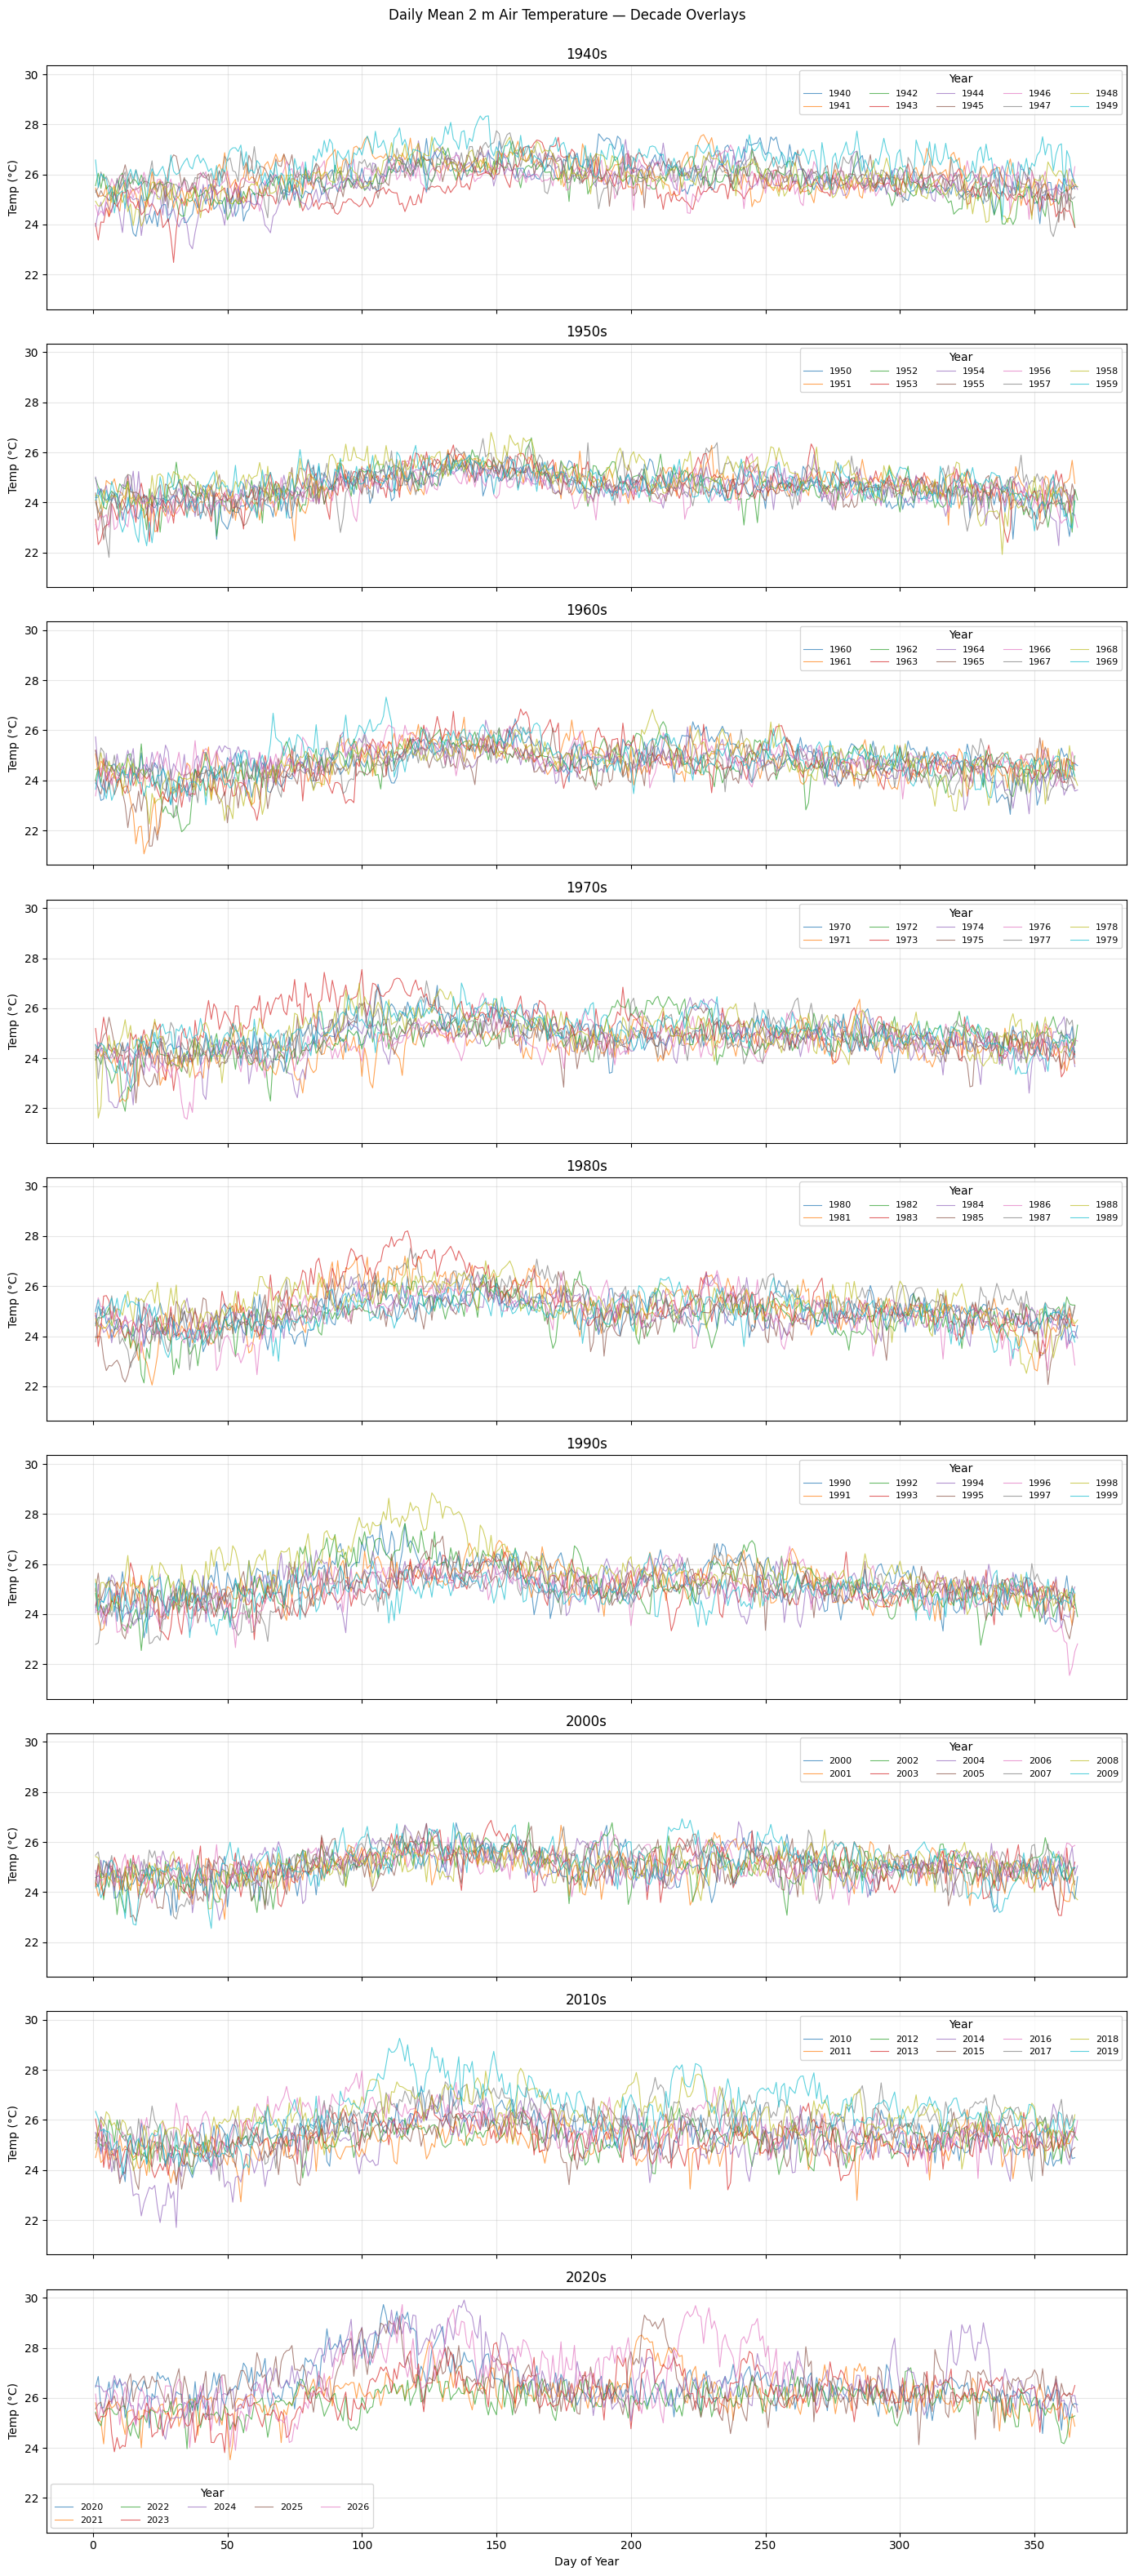

In [6]:
# Daily Mean 2 m Air Temperature — Decade Overlays
decades = get_decades(temp_df)
n = len(decades)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), sharex=True, sharey=True)
if n == 1: axes = [axes]

for ax, (start, yrs) in zip(axes, decades.items()):
    for year in yrs:
        df_y = temp_df[temp_df.index.year == year]
        if not df_y.empty:
            daily = df_y["temp_C"].resample("D").mean()
            ax.plot(daily.index.dayofyear, daily.values, linewidth=0.8, alpha=0.7, label=str(year))
    ax.set_title(f"{start}s")
    ax.set_ylabel("Temp (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Year", ncol=5, fontsize=8)

axes[-1].set_xlabel("Day of Year")
fig.suptitle("Daily Mean 2 m Air Temperature — Decade Overlays", y=1.0)
plt.tight_layout()
plt.show()

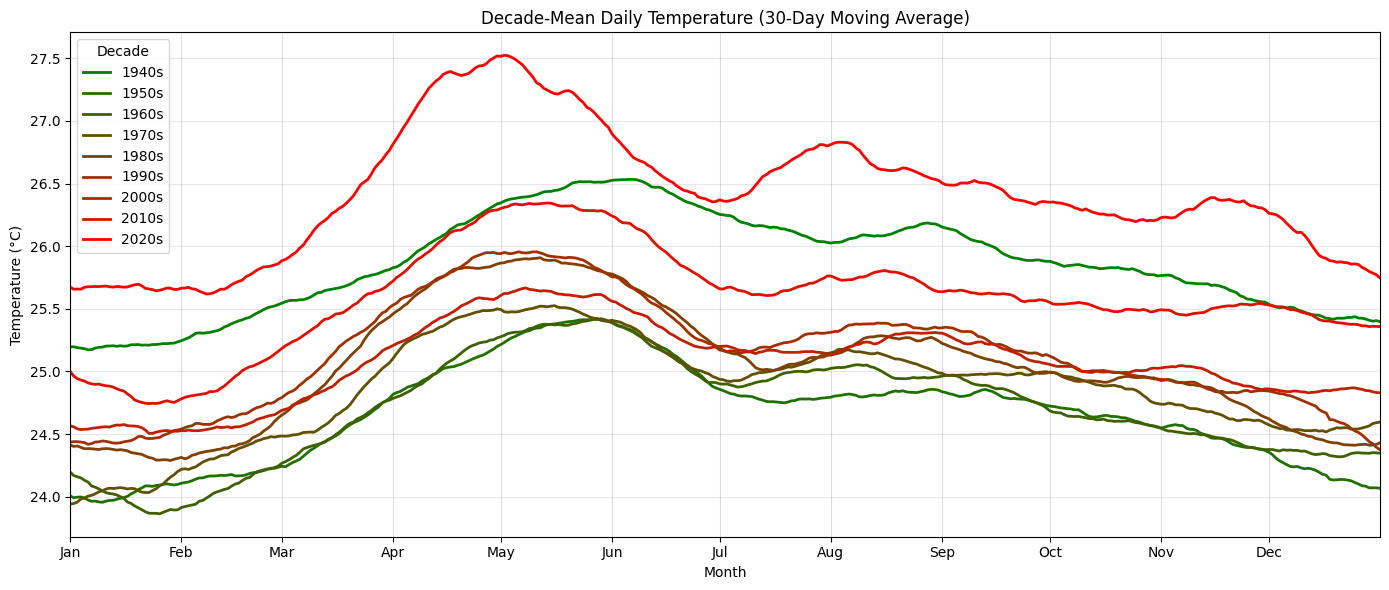

In [7]:
# Decade-Mean Daily Temperature (30-Day Moving Average)
fig, ax = plt.subplots(figsize=(14, 6))
cmap = LinearSegmentedColormap.from_list("green_to_red", ["green", "red"])
colors = [cmap(i / max(n - 1, 1)) for i in range(n)]

decade_df, _ = weighted_by_doy(temp_df, "temp_C", agg="mean")

for i, (start, col) in enumerate(zip(decades.keys(), decade_df.columns)):
    decade_smooth = decade_df[col].rolling(window=30, center=True, min_periods=1).mean()
    ax.plot(decade_smooth.index, decade_smooth.values, linewidth=2, color=colors[i], label=f"{start}s")

ax.set_title("Decade-Mean Daily Temperature (30-Day Moving Average)")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, alpha=0.3)

month_starts = [datetime(1900, m, 1).timetuple().tm_yday for m in range(1, 13)]
month_labels = [datetime(1900, m, 1).strftime("%b") for m in range(1, 13)]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlim(1, 366)
for x in month_starts:
    ax.axvline(x, color="gray", alpha=0.15, linewidth=0.5, zorder=0)

ax.legend(title="Decade")
plt.tight_layout()
plt.show()

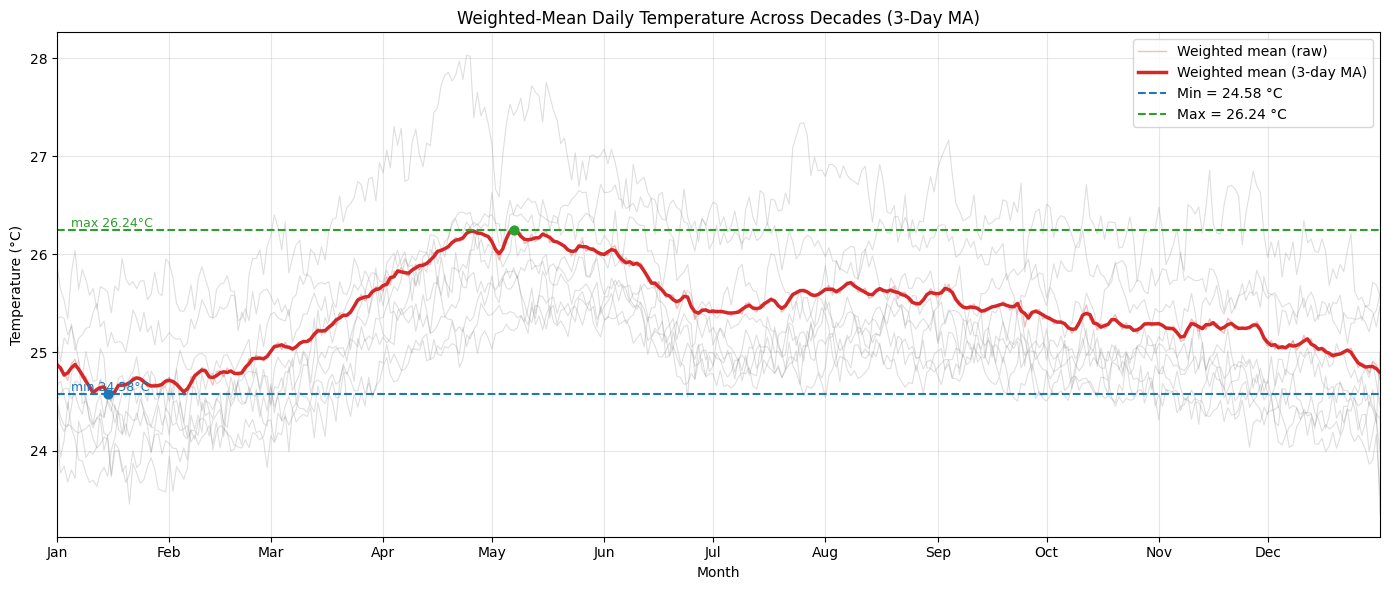

In [8]:
# Weighted-Mean Daily Temperature Across Decades (3-Day MA)
fig, ax = plt.subplots(figsize=(14, 6))

for col in decade_df.columns:
    ax.plot(decade_df.index, decade_df[col], linewidth=0.8, alpha=0.25, color="gray")

_, weighted_overall = weighted_by_doy(temp_df, "temp_C", agg="mean")
weighted_smooth = weighted_overall.rolling(window=3, center=True, min_periods=1).mean()

wmin, wmax = weighted_smooth.min(), weighted_smooth.max()
wmin_doy, wmax_doy = weighted_smooth.idxmin(), weighted_smooth.idxmax()

ax.plot(weighted_overall.index, weighted_overall.values, linewidth=1.0, color="tab:red", alpha=0.3, label="Weighted mean (raw)")
ax.plot(weighted_smooth.index, weighted_smooth.values, linewidth=2.5, color="tab:red", label="Weighted mean (3-day MA)")

ax.axhline(wmin, color="tab:blue", linestyle="--", linewidth=1.5, label=f"Min = {wmin:.2f} °C")
ax.axhline(wmax, color="tab:green", linestyle="--", linewidth=1.5, label=f"Max = {wmax:.2f} °C")
ax.scatter([wmin_doy], [wmin], color="tab:blue", zorder=5, s=40)
ax.scatter([wmax_doy], [wmax], color="tab:green", zorder=5, s=40)
ax.text(5, wmin, f"min {wmin:.2f}°C", color="tab:blue", va="bottom", fontsize=9)
ax.text(5, wmax, f"max {wmax:.2f}°C", color="tab:green", va="bottom", fontsize=9)

ax.set_title("Weighted-Mean Daily Temperature Across Decades (3-Day MA)")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, alpha=0.3)
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlim(1, 366)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Rainfall Analysis

In [9]:
rain_df = load_noaa_csv("CDO_Rain.csv", "rain", "rain_mm")
print(f"Average rainfall per hour: {rain_df['rain_mm'].mean():.3f} mm")

daily_rain = rain_df.groupby(rain_df.index.date)["rain_mm"].sum()
print(f"Average daily rainfall: {daily_rain.mean():.3f} mm/day")

monthly_rain = rain_df.groupby([rain_df.index.year, rain_df.index.month])["rain_mm"].sum()
print(f"Average monthly rainfall: {monthly_rain.mean():.3f} mm/month")

Average rainfall per hour: 0.352 mm
Average daily rainfall: 8.446 mm/day
Average monthly rainfall: 256.941 mm/month


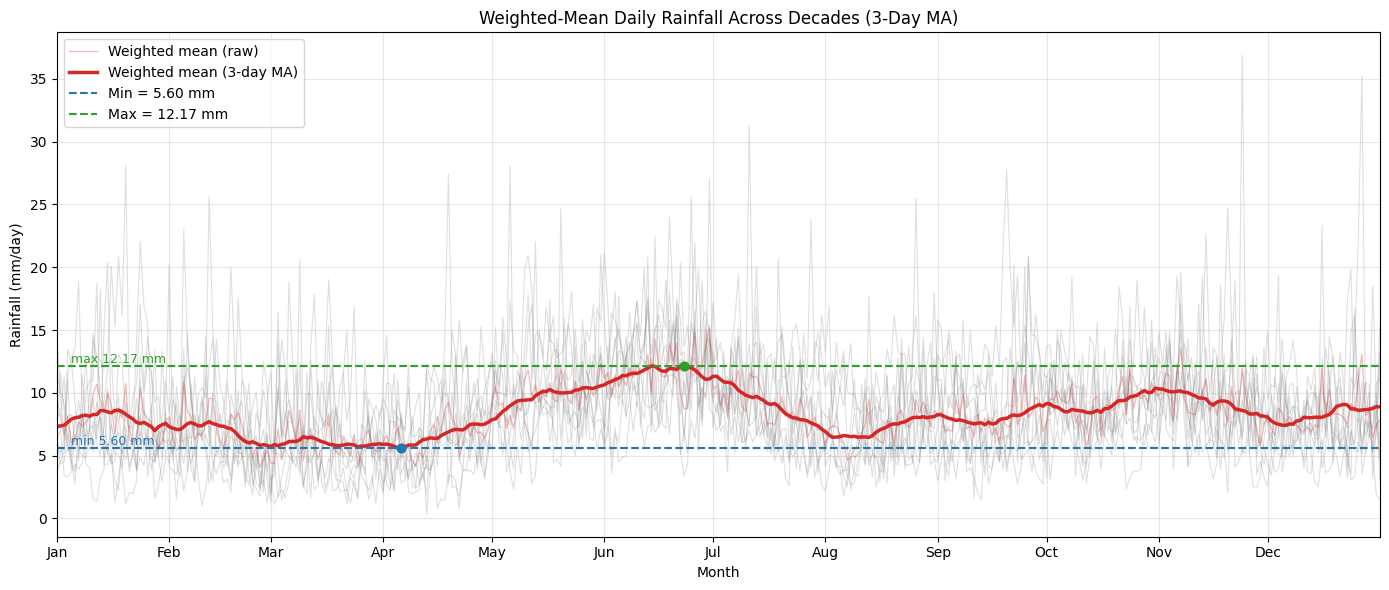

In [14]:
# Weighted-Mean Daily Rainfall Across Decades (3-Day MA)
rain_decade_df, rain_weighted_overall = weighted_by_doy(rain_df, "rain_mm", agg="sum")
rain_weighted_smooth = rain_weighted_overall.rolling(window=15, center=True, min_periods=1).mean()

wmin, wmax = rain_weighted_smooth.min(), rain_weighted_smooth.max()
wmin_doy, wmax_doy = rain_weighted_smooth.idxmin(), rain_weighted_smooth.idxmax()

fig, ax = plt.subplots(figsize=(14, 6))
for col in rain_decade_df.columns:
    ax.plot(rain_decade_df.index, rain_decade_df[col], linewidth=0.8, alpha=0.25, color="gray")

ax.plot(rain_weighted_overall.index, rain_weighted_overall.values, linewidth=1.0, color="tab:red", alpha=0.3, label="Weighted mean (raw)")
ax.plot(rain_weighted_smooth.index, rain_weighted_smooth.values, linewidth=2.5, color="tab:red", label="Weighted mean (3-day MA)")

ax.axhline(wmin, color="tab:blue", linestyle="--", linewidth=1.5, label=f"Min = {wmin:.2f} mm")
ax.axhline(wmax, color="tab:green", linestyle="--", linewidth=1.5, label=f"Max = {wmax:.2f} mm")
ax.scatter([wmin_doy], [wmin], color="tab:blue", zorder=5, s=40)
ax.scatter([wmax_doy], [wmax], color="tab:green", zorder=5, s=40)
ax.text(5, wmin, f"min {wmin:.2f} mm", color="tab:blue", va="bottom", fontsize=9)
ax.text(5, wmax, f"max {wmax:.2f} mm", color="tab:green", va="bottom", fontsize=9)

ax.set_title("Weighted-Mean Daily Rainfall Across Decades (3-Day MA)")
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm/day)")
ax.grid(True, alpha=0.3)
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_xlim(1, 366)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Combined Temperature and Rainfall Analysis

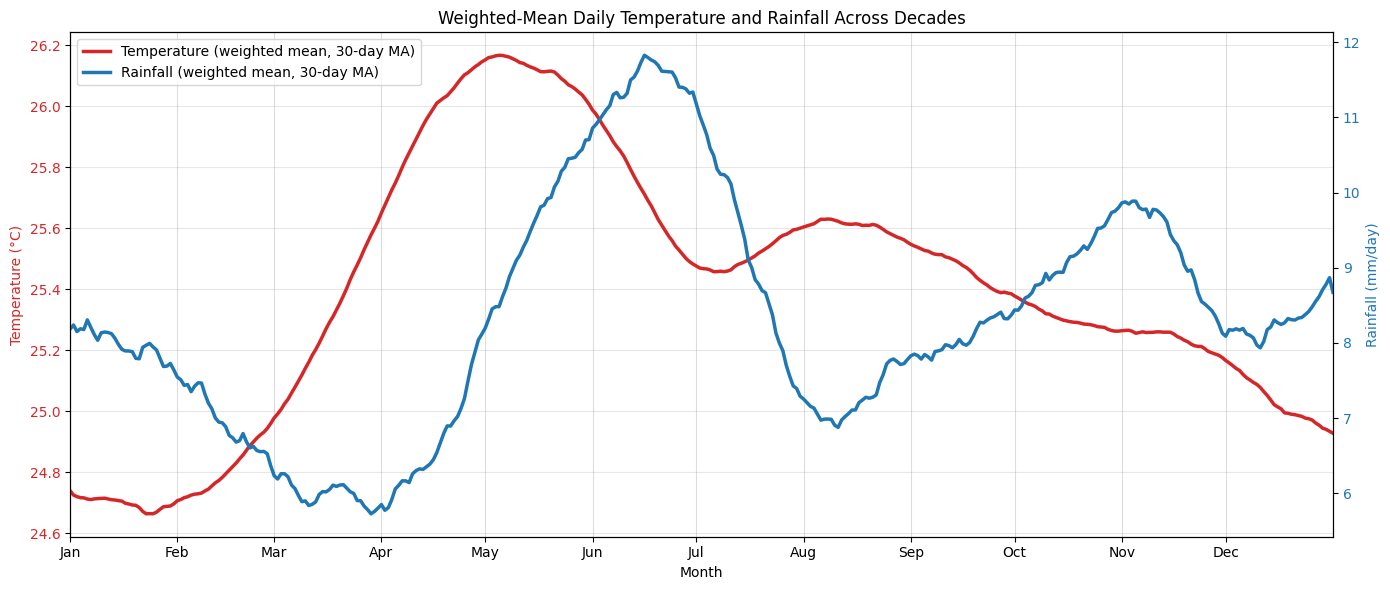

In [12]:
# Smooth both with a 7-day centered moving average
temp_smooth = weighted_overall.rolling(window=30, center=True, min_periods=1).mean()
rain_smooth = rain_weighted_overall.rolling(window=30, center=True, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))

color_temp = "tab:red"
color_rain = "tab:blue"

# Temperature on the left axis
ax1.plot(temp_smooth.index, temp_smooth.values, color=color_temp, linewidth=2.5, label="Temperature (weighted mean, 30-day MA)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Temperature (°C)", color=color_temp)
ax1.tick_params(axis="y", labelcolor=color_temp)

# Rainfall on the right axis
ax2 = ax1.twinx()
ax2.plot(rain_smooth.index, rain_smooth.values, color=color_rain, linewidth=2.5, label="Rainfall (weighted mean, 30-day MA)")
ax2.set_ylabel("Rainfall (mm/day)", color=color_rain)
ax2.tick_params(axis="y", labelcolor=color_rain)

ax1.set_xticks(month_starts)
ax1.set_xticklabels(month_labels)
ax1.set_xlim(1, 366)
for x in month_starts:
    ax1.axvline(x, color="gray", alpha=0.15, linewidth=0.5, zorder=0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Weighted-Mean Daily Temperature and Rainfall Across Decades")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()